# Protein-to-genome mappers: a head-to-head

This notebook **runs the real tools from the terminal** (it shells out to the
benchmark scripts) and compares how they map protein-domain amino-acid
coordinates onto the genome. Nothing here is pre-computed — every number below
is produced by the cells as they run.

We compare three tools that genuinely do the mapping:

| Tool | What it is |
|---|---|
| **prot2exon** | our C++ binary with a pre-built index |
| **ensembldb::proteinToGenome** | the Bioconductor canonical (R, SQLite-backed) |
| **GenomicFeatures::proteinToGenome** | a second Bioconductor implementation (R, in-memory GRanges) |

and we separately characterise two *visualization* tools people sometimes
confuse with mappers (**VisProDom** and **geneplot**).

**Prerequisites** (this is a benchmark notebook — it needs the comparison
environment): the prot2exon binary built under `build/`, R with `ensembldb`,
`GenomicFeatures`, and `EnsDb.Hsapiens.v86` installed, and the v86 query set
(`queries_v86.bed`). See `benchmarks/README.md`.

## The scripts, in plain language

Everything below is driven by a few small scripts in `benchmarks/`. Here is
what each one does, without jargon:

- **`proteintogenome_bench.R <tool> ...`** — runs *one* R mapper (either
  `ensembldb` or `genomicfeatures`) on a batch of queries. It writes two files:
  the genomic intervals it found, and a tiny "timing" file (how long setup took,
  how long the mapping took, and the peak memory the process used). We run it
  once per tool so each tool's memory is measured on its own.

- **`prot2exon map ...`** — the prot2exon command itself. It loads the index
  once, then maps all the queries. It prints how long the load and the mapping
  took.

- **`compare_intervals.py a=... b=... c=...`** — the referee. It reads each
  tool's intervals, reduces every query to a *set of (chrom, start, end, strand)
  pieces*, and checks whether the tools produced **exactly the same pieces**. It
  prints, for each pair of tools, how many queries matched.

- **`visprodom_bench.R <repo>`** — times VisProDom's `CreDat()` function, which
  is the one piece of VisProDom that actually maps domains to the genome. It
  reports how long it takes for 100 / 1,000 / 10,000 domains and the full set.

The point of splitting this into scripts is that the **same scripts** produce
the numbers whether you run them here or from a plain shell — the notebook is
just a convenient driver that runs them and draws the charts.

In [1]:
# --- Setup: locate the repo, data, binary, and the EnsDb, then run from repo root ---
import os, subprocess, re, sys
from pathlib import Path

# Find the repo root (the folder that contains benchmarks/proteintogenome_bench.R)
start = Path.cwd()
REPO = next((p for p in [start, *start.parents]
             if (p / "benchmarks" / "proteintogenome_bench.R").exists()), start)
os.chdir(REPO)
print("repo root :", REPO)

BIN = REPO / "build" / "prot2exon"
DATA = Path(os.environ.get("PROT2EXON_BENCH_DATA",
                           Path.home() / "Desktop" / "protein2genomic_data"))
QUERIES = DATA / "queries_v86.bed"
INDEX = DATA / "human_v86.idx"

# Ask R where the EnsDb.Hsapiens.v86 SQLite lives (robust across machines)
ENSDB = subprocess.run(
    ["Rscript", "-e",
     'cat(system.file("extdata/EnsDb.Hsapiens.v86.sqlite", package="EnsDb.Hsapiens.v86"))'],
    capture_output=True, text=True).stdout.strip()

for label, p in [("binary", BIN), ("queries", QUERIES), ("index", INDEX), ("EnsDb", Path(ENSDB))]:
    print(f"{label:8s}: {p}  {'OK' if Path(p).exists() else 'MISSING'}")

WORK = REPO / "benchmarks" / "_ptg_run"
WORK.mkdir(exist_ok=True)
# Use the first 1,000 queries — enough to compare, and keeps ensembldb (~5 q/s) tractable.
Q1K = WORK / "q1k.bed"
Q1K.write_text("".join(QUERIES.read_text().splitlines(keepends=True)[:1000]))
print("\nwrote", Q1K, "(1000 queries)")

repo root : /home/goguxor/Desktop/protein2genomic
binary  : /home/goguxor/Desktop/protein2genomic/build/prot2exon  OK
queries : /home/goguxor/Desktop/protein2genomic_data/queries_v86.bed  OK
index   : /home/goguxor/Desktop/protein2genomic_data/human_v86.idx  OK
EnsDb   : /home/goguxor/R/library/EnsDb.Hsapiens.v86/extdata/EnsDb.Hsapiens.v86.sqlite  OK

wrote /home/goguxor/Desktop/protein2genomic/benchmarks/_ptg_run/q1k.bed (1000 queries)


## 1. prot2exon

Load the index once and map the 1,000 queries. prot2exon prints its own timers
(`Index loading …` and `Domain mapping …`) and a peak-RSS line we can read.

In [2]:
t = subprocess.run(
    [str(BIN), "map", "--index", str(INDEX), "--bed", str(Q1K),
     "--out-dir", str(WORK / "p2e"), "--output", "coding"],
    capture_output=True, text=True)
print(t.stderr.strip()[-600:])

def grab(pattern, text, cast=float):
    m = re.search(pattern, text)
    return cast(m.group(1)) if m else None

p2e_load_ms = grab(r"Index loading completed in (\d+)ms", t.stderr)
p2e_map_ms  = grab(r"Domain mapping completed in (\d+)ms", t.stderr)
p2e_rss_mb  = grab(r"BENCH_PEAK_RSS_MB (\d+)", t.stderr)
print(f"\nprot2exon: load={p2e_load_ms} ms, map={p2e_map_ms} ms, peak RSS={p2e_rss_mb} MB")

Index loading completed in 1311ms
Loaded 1000 queries from /home/goguxor/Desktop/protein2genomic/benchmarks/_ptg_run/q1k.bed
Domain loading completed in 0ms
Mapped 1000/1000 queries (0 unmapped) in 17ms
Domain mapping completed in 17ms
Wrote /home/goguxor/Desktop/protein2genomic/benchmarks/_ptg_run/p2e/domain_mapping_summary.tsv
Wrote /home/goguxor/Desktop/protein2genomic/benchmarks/_ptg_run/p2e/domain_cds_segments.tsv
Wrote /home/goguxor/Desktop/protein2genomic/benchmarks/_ptg_run/p2e/domain_cds_segments.bed
Memory: current=673MB peak=673MB
BENCH_PEAK_RSS_MB 673

prot2exon: load=1311.0 ms, map=17.0 ms, peak RSS=673.0 MB


## 2. ensembldb::proteinToGenome (R, SQLite-backed)

This is the Bioconductor canonical. It queries the EnsDb (a SQLite database) to
map each protein range. It is the slow one — ~5 queries/second — so this cell
takes a few minutes.

In [3]:
r = subprocess.run(
    ["Rscript", "benchmarks/proteintogenome_bench.R", "ensembldb", ENSDB,
     str(Q1K), str(WORK / "ens_intervals.tsv"), str(WORK / "ens_timing.tsv")],
    capture_output=True, text=True)
print([l for l in r.stdout.splitlines() if l.startswith("RESULT")][0])

RESULT tool=ensembldb setup_s=0.000 map_s=197.128 total_s=197.128 peak_rss_mb=1163


## 3. GenomicFeatures::proteinToGenome (R, in-memory GRanges)

The second Bioconductor implementation. Instead of hitting SQLite per query, it
builds a CDS-by-transcript object once (`cdsBy`, the "setup" time) and then maps
in memory. Faster than ensembldb, but still an R loop.

In [4]:
r = subprocess.run(
    ["Rscript", "benchmarks/proteintogenome_bench.R", "genomicfeatures", ENSDB,
     str(Q1K), str(WORK / "gf_intervals.tsv"), str(WORK / "gf_timing.tsv")],
    capture_output=True, text=True)
print([l for l in r.stdout.splitlines() if l.startswith("RESULT")][0])

RESULT tool=genomicfeatures setup_s=7.539 map_s=47.551 total_s=55.090 peak_rss_mb=1364


## 4. Are the coordinates the same?

The referee script checks whether all three tools produced the **exact same
genomic pieces** for each query.

In [5]:
r = subprocess.run(
    [sys.executable, "benchmarks/compare_intervals.py",
     f"ensembldb={WORK/'ens_intervals.tsv'}",
     f"genomicfeatures={WORK/'gf_intervals.tsv'}",
     f"prot2exon={WORK/'p2e'/'domain_cds_segments.tsv'}"],
    capture_output=True, text=True)
print(r.stdout)

loaded: ensembldb=1000 queries, genomicfeatures=1000 queries, prot2exon=1000 queries

ensembldb        vs genomicfeatures : 1000/1000 exact-segment match (100.00%)
ensembldb        vs prot2exon       : 1000/1000 exact-segment match (100.00%)
genomicfeatures  vs prot2exon       : 1000/1000 exact-segment match (100.00%)



## 5. Putting the numbers together

We read the timing files each R tool wrote, add prot2exon's own timers, and show
the table + two charts (mapping throughput and peak memory).

In [6]:
import pandas as pd
rows = []
for tool, tf in [("ensembldb", WORK/"ens_timing.tsv"), ("genomicfeatures", WORK/"gf_timing.tsv")]:
    d = pd.read_csv(tf, sep="\t").iloc[0].to_dict()
    rows.append({"tool": tool, "setup_s": d["setup_s"], "map_s": d["map_s"],
                 "total_s": d["total_s"], "peak_rss_mb": d["peak_rss_mb"],
                 "map_q_per_s": 1000 / d["map_s"]})
rows.insert(0, {"tool": "prot2exon", "setup_s": p2e_load_ms/1000, "map_s": p2e_map_ms/1000,
                "total_s": (p2e_load_ms + p2e_map_ms)/1000, "peak_rss_mb": p2e_rss_mb,
                "map_q_per_s": 1000 / (p2e_map_ms/1000)})
df = pd.DataFrame(rows).set_index("tool")
df.round(2)

,setup_s,map_s,total_s,peak_rss_mb,map_q_per_s
tool,,,,,
prot2exon,1.31,0.02,1.33,673.0,58823.53
ensembldb,0.00,197.13,197.13,1163.0,5.07
genomicfeatures,7.54,47.55,55.09,1364.0,21.03


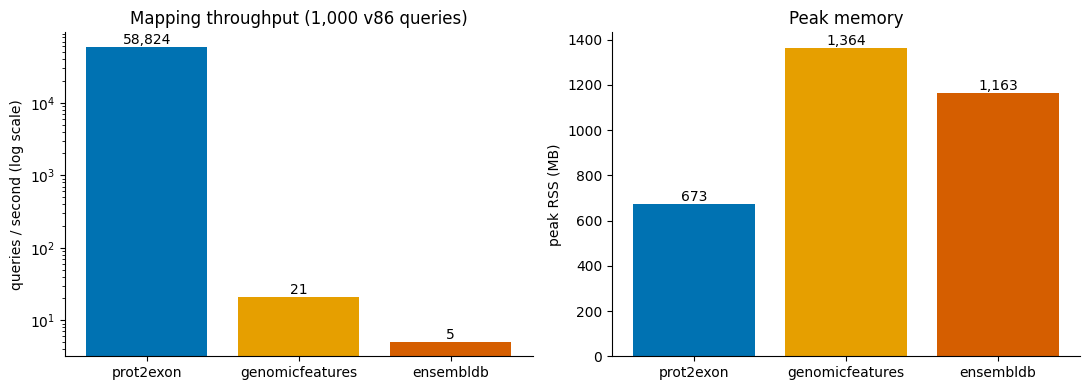

In [7]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
order = ["prot2exon", "genomicfeatures", "ensembldb"]
d = df.loc[order]
colors = ["#0072B2", "#E69F00", "#D55E00"]

ax1.bar(order, d["map_q_per_s"], color=colors)
ax1.set_yscale("log"); ax1.set_ylabel("queries / second (log scale)")
ax1.set_title("Mapping throughput (1,000 v86 queries)")
for i, v in enumerate(d["map_q_per_s"]):
    ax1.text(i, v, f"{v:,.0f}", ha="center", va="bottom")

ax2.bar(order, d["peak_rss_mb"], color=colors)
ax2.set_ylabel("peak RSS (MB)"); ax2.set_title("Peak memory")
for i, v in enumerate(d["peak_rss_mb"]):
    ax2.text(i, v, f"{v:,.0f}", ha="center", va="bottom")
for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 6. VisProDom — a batch mapper with no index

VisProDom is an R/Shiny domain viewer, but its `CreDat()` function genuinely maps
domains to the genome (pure R, same idea as prot2exon). The catch: it has **no
prebuilt index**, so every call rebuilds the entire genome's CDS layout. That
makes it **O(genome), not O(queries)** — mapping 100 domains costs almost the
same as mapping 10,000. We run it on its own bundled maize example.

In [8]:
vpd = Path("/tmp/VisProDom")
if not vpd.exists():
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/whweve/VisProDom", str(vpd)],
                   capture_output=True, text=True)
r = subprocess.run(["Rscript", "benchmarks/visprodom_bench.R", str(vpd)],
                   capture_output=True, text=True)
print("\n".join(l for l in r.stdout.splitlines() if l.startswith("VPD")))

VPD N=100    wall_s=6.13 mapped_rows=61483 peak_rss_mb=763
VPD N=1000   wall_s=4.80 mapped_rows=65358 peak_rss_mb=847
VPD N=10000  wall_s=6.32 mapped_rows=101154 peak_rss_mb=858
VPD FULL     wall_s=12.84 mapped_rows=262392 peak_rss_mb=933


**Read that as:** the wall time is flat (~6–8 s) whether 100 or 10,000
domains are mapped, because the cost is rebuilding the maize gene models, not the
number of domains. prot2exon's persistent index is exactly what removes this
per-call rebuild.

## 7. geneplot — not a mapper

For completeness: **geneplot** (Python) is a *plotting* library built on
`gffutils` + BioPython `GenomeDiagram`. It draws domains that are **already**
mapped (it reads a GFF3 + an InterProScan file). It does no protein→genome
coordinate mapping, so it isn't in the comparison above — it's a peer of
prot2exon's plotting, not its mapper.

## Takeaways

- **Same answers:** prot2exon, ensembldb, and GenomicFeatures return identical
  genomic coordinates (the referee shows 1,000/1,000).
- **Very different speed:** prot2exon maps in milliseconds; GenomicFeatures is
  faster than ensembldb (in-memory GRanges beats SQLite) but both are R loops,
  thousands of times slower per query, at more memory.
- **Indexing matters:** VisProDom shows what happens without an index — you pay
  the whole-genome cost on every call.